# O4 · L2 — Modelo de dos etapas (régimen → posición), pipeline causal

Ejecuta `build_o4_l2` y genera los 7 artefactos (D1, D2, C1..C5)
comparando L2-v1 (dos etapas) contra O4 causal monolítico (L2-v0).

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tfg_aves.ml._paths import CELLS_PARQUET, FEATURES_O3_PARQUET, O4_L2V1_DIR, O4_OUT_DIR
from tfg_aves.ml.build_l2 import _feature_cols, _prepare_causal_splits, build_o4_l2
from tfg_aves.ml.evaluate import evaluate_by_state
from tfg_aves.ml.two_stage import derive_y_move
from tfg_aves.reporting import save_artifact

result = build_o4_l2()
print("filas train/val/test:", result.n_rows_train, result.n_rows_val, result.n_rows_test)
print("movimientos en train:", result.n_moves_train)
print("tau* por combo:", result.tau_star)

metrics_l2 = pd.read_parquet(O4_L2V1_DIR / "metrics.parquet")
metrics_v0 = pd.read_parquet(O4_OUT_DIR / "metrics.parquet")  # O4 causal
preds_soft = pd.read_parquet(O4_L2V1_DIR / "predictions_test_soft.parquet")
preds_v0 = pd.read_parquet(O4_OUT_DIR / "predictions_test.parquet")  # O4 causal

# Splits causales (para D1 y para reconstruir y_move/cell_id_t del test).
features_o3 = pd.read_parquet(FEATURES_O3_PARQUET)
cells = pd.read_parquet(CELLS_PARQUET)
splits = _prepare_causal_splits(features_o3, cells, seed=0)
_, _, test_pob = splits["poblacional"]
feat_pob = _feature_cols("poblacional")
y_move_test = derive_y_move(test_pob).to_numpy().astype(int)

filas train/val/test: 14532 1619 4037
movimientos en train: 4072
tau* por combo: {'rf_personalizado': 0.7, 'rf_poblacional': 0.7, 'xgb_personalizado': 0.7, 'xgb_poblacional': 0.7}


## D1 — Calidad bruta del clasificador de movimiento (etapa 1)

In [2]:
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)

rows = []
for fam in ("rf", "xgb"):
    bundle = joblib.load(O4_L2V1_DIR / f"model_clf_move_{fam}.pkl")
    clf = bundle["model"]
    pos = list(clf.classes_).index(1)
    p = clf.predict_proba(test_pob[feat_pob])[:, pos]
    yhat = (p >= 0.5).astype(int)
    rows.append({
        "familia": fam,
        "auc": roc_auc_score(y_move_test, p),
        "accuracy": accuracy_score(y_move_test, yhat),
        "brier": brier_score_loss(y_move_test, p),
        "precision_mov": precision_score(y_move_test, yhat, zero_division=0),
        "recall_mov": recall_score(y_move_test, yhat, zero_division=0),
    })
d1 = pd.DataFrame(rows).round(4)
print(d1.to_string(index=False))

save_artifact(
    "l2v1-clf-move-quality",
    objective="o4", num=17,
    decision="Calidad bruta del clasificador de movimiento (etapa 1)",
    caption_es=(
        "Métricas del clasificador binario de movimiento (etapa 1) sobre el "
        "test temporal: AUC, accuracy, Brier score y precision/recall de la "
        "clase movimiento, para RF y XGBoost. Justifica que la etapa 1 "
        "discrimina movimiento con calibración aceptable."
    ),
    table=d1,
)

familia    auc  accuracy  brier  precision_mov  recall_mov
     rf 0.8613    0.8353 0.1160         0.7341      0.4196
    xgb 0.8560    0.8340 0.1178         0.7380      0.4064


ArtifactPaths(figure=None, figure_pdf=None, table=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/tables/o4_tab17_l2v1-clf-move-quality.csv'), caption=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/captions/o4_tab17_l2v1-clf-move-quality.md'), ref='o4_tab17_l2v1-clf-move-quality')

## D2 — Barrido de τ (regla hard)

ArtifactPaths(figure=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/figures/o4_fig18_l2v1-tau-sweep.png'), figure_pdf=None, table=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/tables/o4_tab18_l2v1-tau-sweep.csv'), caption=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/captions/o4_fig18_l2v1-tau-sweep.md'), ref='o4_fig18_l2v1-tau-sweep')

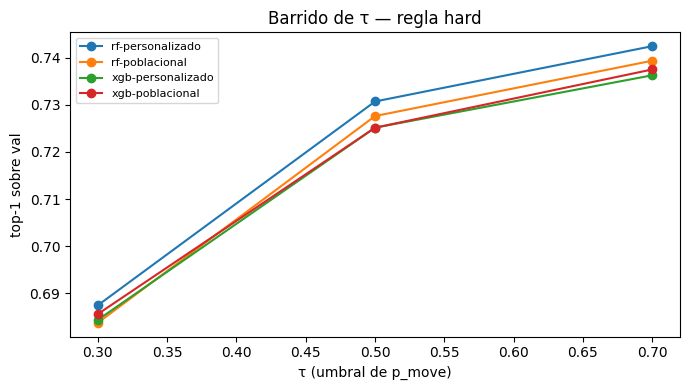

In [3]:
tau_df = pd.read_parquet(O4_L2V1_DIR / "tau_sweep.parquet")
fig, ax = plt.subplots(figsize=(7, 4))
for (fam, modo), sub in tau_df.groupby(["modelo", "modo"]):
    ax.plot(sub["tau"], sub["top1"], marker="o", label=f"{fam}-{modo}")
ax.set_xlabel("τ (umbral de p_move)")
ax.set_ylabel("top-1 sobre val")
ax.set_title("Barrido de τ — regla hard")
ax.legend(fontsize=8)
fig.tight_layout()

save_artifact(
    "l2v1-tau-sweep",
    objective="o4", num=18,
    decision="τ* de la regla hard elegido por top-1 sobre val",
    caption_es=(
        "Top-1 sobre el conjunto de validación en función del umbral τ de la "
        "regla hard, por familia y modo. Se selecciona el τ que maximiza "
        "top-1; el log-loss no se usa por ser degenerado para una regla "
        "one-hot."
    ),
    fig=fig, table=tau_df,
)

## C1 — Comparativa global L2-v0 (O4 causal) vs L2-v1

      modelo          modo   top1   top3  log_loss  dist_median_km version  regla
persistencia             — 0.7751 0.7751       NaN         20.9567   L2-v0 argmax
      markov             — 0.5482 0.6322       NaN         24.9026   L2-v0 argmax
          rf personalizado 0.5796 0.7350    5.6657         24.0483   L2-v0 argmax
         xgb personalizado 0.5923 0.7015    5.7924         24.0351   L2-v0 argmax
        lgbm personalizado 0.3584 0.5474   13.3378        121.6732   L2-v0 argmax
          rf   poblacional 0.5695 0.7250    5.8358         24.3493   L2-v0 argmax
         xgb   poblacional 0.5811 0.7008    5.8271         24.3459   L2-v0 argmax
        lgbm   poblacional 0.3797 0.5898   13.2195         97.9473   L2-v0 argmax
          rf personalizado 0.7798 0.8692    2.8058         20.8895   L2-v1   soft
          rf personalizado 0.7716 0.7736       NaN         20.9567   L2-v1   hard
          rf   poblacional 0.7795 0.8662    2.8211         20.9074   L2-v1   soft
          rf   p

ArtifactPaths(figure=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/figures/o4_fig19_l2v1-metrics-comparison.png'), figure_pdf=None, table=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/tables/o4_tab19_l2v1-metrics-comparison.csv'), caption=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/captions/o4_fig19_l2v1-metrics-comparison.md'), ref='o4_fig19_l2v1-metrics-comparison')

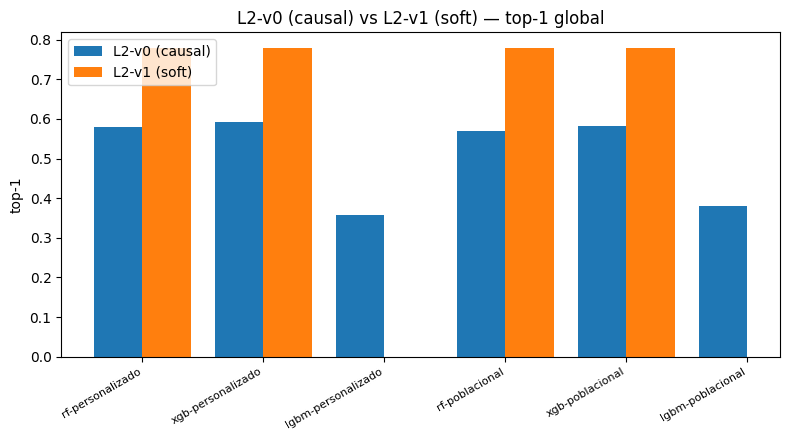

In [4]:
v0 = metrics_v0[metrics_v0.get("split", "test") == "test"][
    ["modelo", "modo", "top1", "top3", "log_loss", "dist_median_km"]
].assign(version="L2-v0", regla="argmax")
v1 = metrics_l2[metrics_l2["regla"].isin(["soft", "hard"])][
    ["modelo", "modo", "regla", "top1", "top3", "log_loss", "dist_median_km"]
].assign(version="L2-v1")
c1 = pd.concat([v0, v1], ignore_index=True).round(4)
print(c1.to_string(index=False))

base = c1[(c1["version"] == "L2-v0") & (c1["modo"].isin(["personalizado", "poblacional"]))]
soft = c1[(c1["version"] == "L2-v1") & (c1["regla"] == "soft")]
labels = [f"{r.modelo}-{r.modo}" for r in base.itertuples()]
x = np.arange(len(labels))
soft_aligned = (
    soft.set_index(["modelo", "modo"])
    .reindex(base.set_index(["modelo", "modo"]).index)["top1"].to_numpy()
)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - 0.2, base["top1"], width=0.4, label="L2-v0 (causal)")
ax.bar(x + 0.2, soft_aligned, width=0.4, label="L2-v1 (soft)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("top-1")
ax.set_title("L2-v0 (causal) vs L2-v1 (soft) — top-1 global")
ax.legend()
fig.tight_layout()

save_artifact(
    "l2v1-metrics-comparison",
    objective="o4", num=19,
    decision="Comparativa global L2-v0 (O4 causal) vs L2-v1 (entregable central de L2)",
    caption_es=(
        "Comparativa de métricas globales entre el modelo monolítico de O4 "
        "causal (L2-v0) y el modelo de dos etapas (L2-v1), con reglas soft y "
        "hard. El log-loss de la regla hard se omite por no ser comparable."
    ),
    fig=fig, table=c1,
)

## C2 — Comparativa por estado HMM (estacionario vs migración)

El lift esperado de L2 está en migración. Comparamos L2-v1 soft contra
O4 causal (L2-v0) para los dos ganadores por familia.

     version modelo          modo        state  n_obs   top1   top3  dist_median_km
L2-v0 causal     rf personalizado       global   4037 0.5796 0.7350         24.0483
L2-v0 causal     rf personalizado estacionario   3566 0.6388 0.7984         22.9272
L2-v0 causal     rf personalizado    migración    471 0.1316 0.2548        274.7619
  L2-v1 soft     rf personalizado       global   4037 0.7798 0.8692         20.8895
  L2-v1 soft     rf personalizado estacionario   3566 0.8466 0.9319         19.4039
  L2-v1 soft     rf personalizado    migración    471 0.2739 0.3949         54.6845
L2-v0 causal    xgb   poblacional       global   4037 0.5811 0.7008         24.3459
L2-v0 causal    xgb   poblacional estacionario   3566 0.6391 0.7625         23.0850
L2-v0 causal    xgb   poblacional    migración    471 0.1423 0.2335        164.5154
  L2-v1 soft    xgb   poblacional       global   4037 0.7790 0.8628         20.9122
  L2-v1 soft    xgb   poblacional estacionario   3566 0.8460 0.9296         

ArtifactPaths(figure=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/figures/o4_fig20_l2v1-by-state-comparison.png'), figure_pdf=None, table=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/tables/o4_tab20_l2v1-by-state-comparison.csv'), caption=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/captions/o4_fig20_l2v1-by-state-comparison.md'), ref='o4_fig20_l2v1-by-state-comparison')

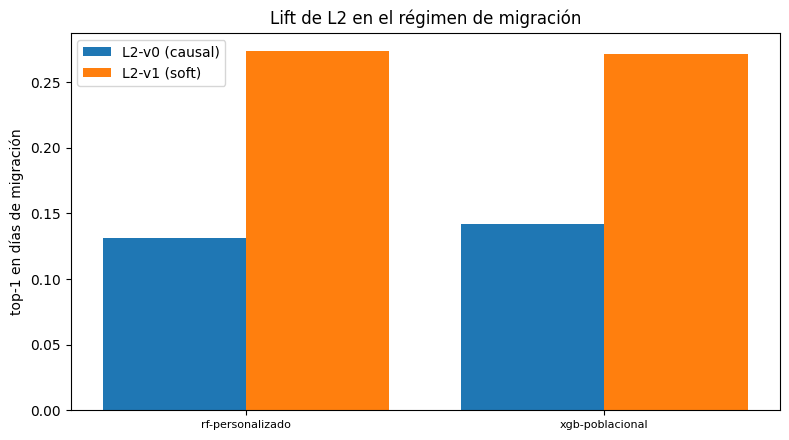

In [5]:
def _by_state_for(df_preds, modelo, modo):
    sub = df_preds[(df_preds["modelo"] == modelo) & (df_preds["modo"] == modo)].copy()
    tbl = evaluate_by_state(sub, state_col="state_b_causal")
    tbl["modelo"] = modelo
    tbl["modo"] = modo
    return tbl


combos = [("rf", "personalizado"), ("xgb", "poblacional")]
c2_parts = []
for modelo, modo in combos:
    v1_tbl = _by_state_for(preds_soft, modelo, modo).assign(version="L2-v1 soft")
    v0_tbl = _by_state_for(preds_v0, modelo, modo).assign(version="L2-v0 causal")
    c2_parts += [v0_tbl, v1_tbl]
c2 = pd.concat(c2_parts, ignore_index=True).round(4)
c2 = c2[["version", "modelo", "modo", "state", "n_obs", "top1", "top3", "dist_median_km"]]
print(c2.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
mig = c2[c2["state"] == "migración"].copy()
mig["etq"] = mig["modelo"] + "-" + mig["modo"]
labels = mig["etq"].unique().tolist()
x = np.arange(len(labels))
v0_top1 = mig[mig["version"] == "L2-v0 causal"].set_index("etq").reindex(labels)["top1"].to_numpy()
v1_top1 = mig[mig["version"] == "L2-v1 soft"].set_index("etq").reindex(labels)["top1"].to_numpy()
ax.bar(x - 0.2, v0_top1, width=0.4, label="L2-v0 (causal)")
ax.bar(x + 0.2, v1_top1, width=0.4, label="L2-v1 (soft)")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("top-1 en días de migración")
ax.set_title("Lift de L2 en el régimen de migración")
ax.legend()
fig.tight_layout()

save_artifact(
    "l2v1-by-state-comparison",
    objective="o4", num=20,
    decision="Comparativa por estado HMM (estacionario/migración) L2-v0 vs L2-v1",
    caption_es=(
        "Métricas por régimen biológico (estacionario vs migración, según "
        "state_b_causal) para los dos modelos ganadores. El núcleo del valor "
        "de L2 es el comportamiento en días de migración, el régimen donde el "
        "modelo monolítico de O4 fracasa."
    ),
    fig=fig, table=c2,
)

## C3 — Subset "moves only" (verdad y_move=1): calidad de la etapa 2B

In [6]:
# L2-v1: top1_moves / dist_median_km_moves ya están en metrics.parquet (soft).
l2_moves = metrics_l2[metrics_l2["regla"] == "soft"][
    ["modelo", "modo", "top1_moves", "dist_median_km_moves"]
].rename(columns={"top1_moves": "top1", "dist_median_km_moves": "dist_median_km"})
l2_moves = l2_moves.assign(version="L2-v1 soft")

# O4 causal: reconstruir y_move sobre su test y filtrar sus predicciones.
# preds_v0 trae (bird_id, date_utc) alineables con test_pob (cell_id_t).
cellt_by_key = test_pob.set_index(["bird_id", "date_utc"])["cell_id_t"]
v0_rows = []
for modelo, modo in combos:
    sub = preds_v0[(preds_v0["modelo"] == modelo) & (preds_v0["modo"] == modo)].copy()
    key = list(zip(sub["bird_id"], sub["date_utc"], strict=True))
    sub["cell_id_t"] = cellt_by_key.reindex(key).to_numpy()
    mask = sub["cell_id_t"].astype(str) != sub["true_cell"].astype(str)
    sub_m = sub[mask]
    v0_rows.append({
        "version": "L2-v0 causal", "modelo": modelo, "modo": modo,
        "top1": float((sub_m["true_cell"] == sub_m["pred_cell_top1"]).mean()),
        "dist_median_km": float(np.median(sub_m["pred_dist_km"])),
    })
c3 = pd.concat(
    [pd.DataFrame(v0_rows), l2_moves[["version", "modelo", "modo", "top1", "dist_median_km"]]],
    ignore_index=True,
).round(4)
print(c3.to_string(index=False))

save_artifact(
    "l2v1-moves-only",
    objective="o4", num=21,
    decision="Calidad de la etapa 2B sobre el subset de días con movimiento real",
    caption_es=(
        "Métricas restringidas al subconjunto del test donde el ave "
        "verdaderamente cambia de celda (y_move=1), para L2-v0 (O4 causal) y "
        "L2-v1 soft. Aísla la calidad del clasificador de destino sin que la "
        "persistencia trivial domine la métrica global."
    ),
    table=c3,
)

     version modelo          modo   top1  dist_median_km
L2-v0 causal     rf personalizado 0.1707         53.5206
L2-v0 causal    xgb   poblacional 0.1817         53.1549
  L2-v1 soft     rf personalizado 0.0374         42.9242
  L2-v1 soft     rf   poblacional 0.0363         42.9944
  L2-v1 soft    xgb personalizado 0.0430         43.0593
  L2-v1 soft    xgb   poblacional 0.0407         43.1291


ArtifactPaths(figure=None, figure_pdf=None, table=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/tables/o4_tab21_l2v1-moves-only.csv'), caption=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/captions/o4_tab21_l2v1-moves-only.md'), ref='o4_tab21_l2v1-moves-only')

## C4 — Gap train-test de la etapa 2B (sobreajuste por dataset reducido)

modelo          modo  top1_train  top1_test    gap
    rf personalizado      0.6670     0.2963 0.3707
    rf   poblacional      0.6559     0.2919 0.3641
   xgb personalizado      0.5096     0.2852 0.2243
   xgb   poblacional      0.4944     0.2852 0.2091


ArtifactPaths(figure=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/figures/o4_fig22_l2v1-gap-train-test.png'), figure_pdf=None, table=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/tables/o4_tab22_l2v1-gap-train-test.csv'), caption=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/captions/o4_fig22_l2v1-gap-train-test.md'), ref='o4_fig22_l2v1-gap-train-test')

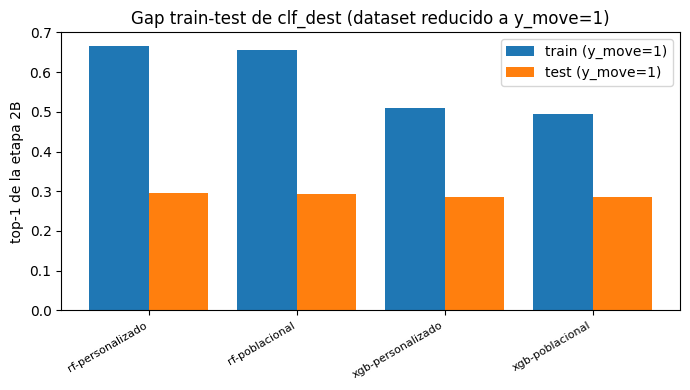

In [7]:
train_pob = splits["poblacional"][0]
y_move_train = derive_y_move(train_pob).to_numpy().astype(bool)
gap_rows = []
for modelo, modo in [("rf", "personalizado"), ("rf", "poblacional"),
                     ("xgb", "personalizado"), ("xgb", "poblacional")]:
    bundle = joblib.load(O4_L2V1_DIR / f"model_clf_dest_{modelo}_{modo}.pkl")
    clf = bundle["model"]
    le = bundle["label_encoder_y"]
    feat = bundle["feature_cols"]
    train_m = splits[modo][0]
    test_m = splits[modo][2]
    tr_moves = train_m[y_move_train].reset_index(drop=True)
    # top-1 en train (subset y_move=1) — etiquetas conocidas por el encoder
    known = set(le.classes_)
    tr_known = tr_moves[tr_moves["cell_id_t_next"].astype(str).isin(known)]
    pred_tr = le.inverse_transform(clf.predict(tr_known[feat]))
    top1_tr = float((pred_tr == tr_known["cell_id_t_next"].astype(str).to_numpy()).mean())
    # top-1 en test (subset y_move=1 real)
    ym_test = derive_y_move(test_m).to_numpy().astype(bool)
    te_moves = test_m[ym_test].reset_index(drop=True)
    pred_te = le.inverse_transform(clf.predict(te_moves[feat]))
    top1_te = float((pred_te == te_moves["cell_id_t_next"].astype(str).to_numpy()).mean())
    gap_rows.append({
        "modelo": modelo, "modo": modo,
        "top1_train": round(top1_tr, 4), "top1_test": round(top1_te, 4),
        "gap": round(top1_tr - top1_te, 4),
    })
c4 = pd.DataFrame(gap_rows)
print(c4.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
etq = (c4["modelo"] + "-" + c4["modo"]).tolist()
x = np.arange(len(etq))
ax.bar(x - 0.2, c4["top1_train"], width=0.4, label="train (y_move=1)")
ax.bar(x + 0.2, c4["top1_test"], width=0.4, label="test (y_move=1)")
ax.set_xticks(x)
ax.set_xticklabels(etq, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("top-1 de la etapa 2B")
ax.set_title("Gap train-test de clf_dest (dataset reducido a y_move=1)")
ax.legend()
fig.tight_layout()

save_artifact(
    "l2v1-gap-train-test",
    objective="o4", num=22,
    decision="Gap train-test de la etapa 2B para vigilar sobreajuste (R2)",
    caption_es=(
        "Top-1 de la etapa 2B (clf_dest) sobre su propio conjunto de "
        "entrenamiento (filas con movimiento) frente al test, por familia y "
        "modo. Vigila el sobreajuste derivado de entrenar el clasificador de "
        "destino sobre un subconjunto reducido (~movimientos del train)."
    ),
    fig=fig, table=c4,
)

## C5 — Matriz de confusión: estado HMM real × decisión de cambio de celda

Para el ganador L2-v1 soft (RF personalizado) vs O4 causal. Diagnostica
cuándo cada modelo decide "cambiar de celda" en función del régimen real.

              L2-v0:cambio=False  L2-v0:cambio=True  L2-v1:cambio=False  L2-v1:cambio=True
regimen                                                                                   
estacionario               0.665              0.335               0.987              0.013
migración                  0.183              0.817               0.917              0.083


ArtifactPaths(figure=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/figures/o4_fig23_l2v1-state-confusion.png'), figure_pdf=None, table=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/tables/o4_tab23_l2v1-state-confusion.csv'), caption=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/captions/o4_fig23_l2v1-state-confusion.md'), ref='o4_fig23_l2v1-state-confusion')

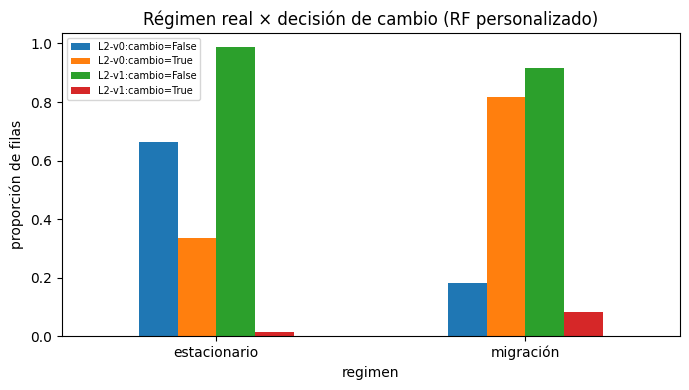

In [8]:
def _change_table(df_preds, modelo, modo, label):
    sub = df_preds[(df_preds["modelo"] == modelo) & (df_preds["modo"] == modo)].copy()
    key = list(zip(sub["bird_id"], sub["date_utc"], strict=True))
    sub["cell_id_t"] = cellt_by_key.reindex(key).to_numpy()
    sub["predice_cambio"] = (
        sub["pred_cell_top1"].astype(str) != sub["cell_id_t"].astype(str)
    )
    sub["regimen"] = sub["state_b_causal"].map({0: "estacionario", 1: "migración"})
    ct = pd.crosstab(sub["regimen"], sub["predice_cambio"], normalize="index").round(3)
    ct.columns = [f"{label}:cambio={c}" for c in ct.columns]
    return ct


c5_v1 = _change_table(preds_soft, "rf", "personalizado", "L2-v1")
c5_v0 = _change_table(preds_v0, "rf", "personalizado", "L2-v0")
c5 = c5_v0.join(c5_v1)
print(c5.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
c5.plot(kind="bar", ax=ax)
ax.set_ylabel("proporción de filas")
ax.set_title("Régimen real × decisión de cambio (RF personalizado)")
ax.set_xticklabels(c5.index, rotation=0)
ax.legend(fontsize=7)
fig.tight_layout()

save_artifact(
    "l2v1-state-confusion",
    objective="o4", num=23,
    decision="Régimen HMM real frente a la decisión de cambio de celda (L2-v1 vs L2-v0)",
    caption_es=(
        "Proporción de días en que cada modelo predice un cambio de celda, "
        "desglosada por el régimen real (state_b_causal) para el ganador RF "
        "personalizado. Diagnostica si la arquitectura de dos etapas cambia "
        "su comportamiento de decisión respecto al modelo monolítico."
    ),
    fig=fig, table=c5.reset_index(),
)